In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nicoleudoh/fakenewsnetdataset/politifact_real.csv
/kaggle/input/datasets/nicoleudoh/fakenewsnetdataset/politifact_fake.csv
/kaggle/input/datasets/nicoleudoh/fakenewsnetdataset/gossipcop_real.csv
/kaggle/input/datasets/nicoleudoh/fakenewsnetdataset/gossipcop_fake.csv


In [6]:
import os 
#List the files in kaggle input directory to verify that dataset has been uploaded 
print(os.listdir("/kaggle/input/"))

['datasets']


In [7]:
# Display all files inside the FakeNewsNet dataset folder 
# Confirms that the CSV files are present 
print (os.listdir("/kaggle/input/datasets/nicoleudoh/fakenewsnetdataset"))

['politifact_real.csv', 'politifact_fake.csv', 'gossipcop_real.csv', 'gossipcop_fake.csv']


In [8]:
import pandas as pd
#define the file path to the dataset directory 
path = "/kaggle/input/datasets/nicoleudoh/fakenewsnetdataset/"
# Loading all four CSV files separately before merging
# because each file needs to be labelled first
# (if I merged first I wouldn't know which rows are fake vs real)
politifact_fake = pd.read_csv(path + "politifact_fake.csv")
politifact_real = pd.read_csv(path + "politifact_real.csv")
gossipcop_fake = pd.read_csv(path + "gossipcop_fake.csv")
gossipcop_real = pd.read_csv(path + "gossipcop_real.csv")


In [9]:
# Assigning binary labels for supervised classification
# Fake news =1 , Real news = 0
politifact_fake["label"]= 1
politifact_real["label"]= 0
gossipcop_fake["label"]= 1
gossipcop_real["label"]= 0 

In [10]:
# Combine all datasets into a single Dataframe 
# ignore_index= True resets the row numbers so there are no duplicate indices
df = pd.concat([
    politifact_fake,
    politifact_real,
    gossipcop_fake,
    gossipcop_real],
    ignore_index=True)
              

In [11]:
# Display the first few rows of the dataset to understand the structure and contents
print(df.head())

# Display the shape of the dataset 
print(df.shape)

# Display column names 
print(df.columns)

                id                                           news_url  \
0  politifact15014          speedtalk.com/forum/viewtopic.php?t=51650   
1  politifact15156  politics2020.info/index.php/2018/03/13/court-o...   
2  politifact14745  www.nscdscamps.org/blog/category/parenting/467...   
3  politifact14355  https://howafrica.com/oscar-pistorius-attempts...   
4  politifact15371  http://washingtonsources.org/trump-votes-for-d...   

                                               title  \
0  BREAKING: First NFL Team Declares Bankruptcy O...   
1  Court Orders Obama To Pay $400 Million In Rest...   
2  UPDATE: Second Roy Moore Accuser Works For Mic...   
3         Oscar Pistorius Attempts To Commit Suicide   
4        Trump Votes For Death Penalty For Being Gay   

                                           tweet_ids  label  
0  937349434668498944\t937379378006282240\t937380...      1  
1  972666281441878016\t972678396575559680\t972827...      1  
2  929405740732870656\t929439450400264

In [12]:
# Count the number of fake (1) and real (0) news occurrence 
# Helps identify class imbalnce in the dataset
print(df["label"].value_counts())

label
0    17441
1     5755
Name: count, dtype: int64


In [13]:
# Keep only the title and label columns
df = df[["title", "label"]].copy()

# Remove row with mising title values
# a model can't learn from an empty input
df = df.dropna(subset=["title"])

# Rename the title column to text to make column names consistent
df = df.rename(columns={'title':'text'})

# Check the cleaned result
print(df.head())
print(df.shape)
print(df["label"].value_counts())


                                                text  label
0  BREAKING: First NFL Team Declares Bankruptcy O...      1
1  Court Orders Obama To Pay $400 Million In Rest...      1
2  UPDATE: Second Roy Moore Accuser Works For Mic...      1
3         Oscar Pistorius Attempts To Commit Suicide      1
4        Trump Votes For Death Penalty For Being Gay      1
(23196, 2)
label
0    17441
1     5755
Name: count, dtype: int64


In [14]:
import re

# Function to clean text data
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

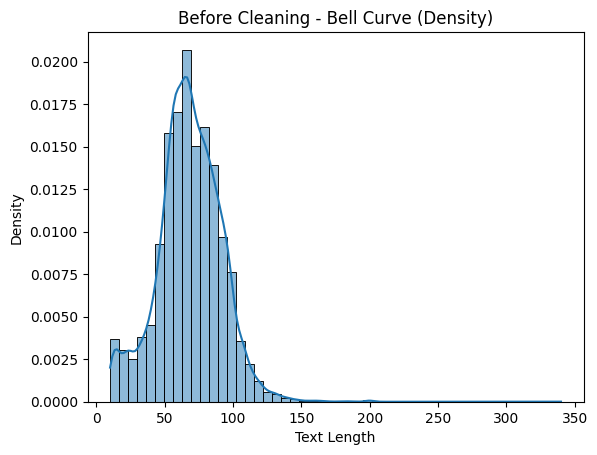

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# BEFORE CLEANING
df["text_length_before"] = df["text"].apply(lambda x: len(str(x)))

sns.histplot(df["text_length_before"], bins=50, kde=True, stat="density")
plt.title("Before Cleaning - Bell Curve (Density)")
plt.xlabel("Text Length")
plt.ylabel("Density")
plt.show()

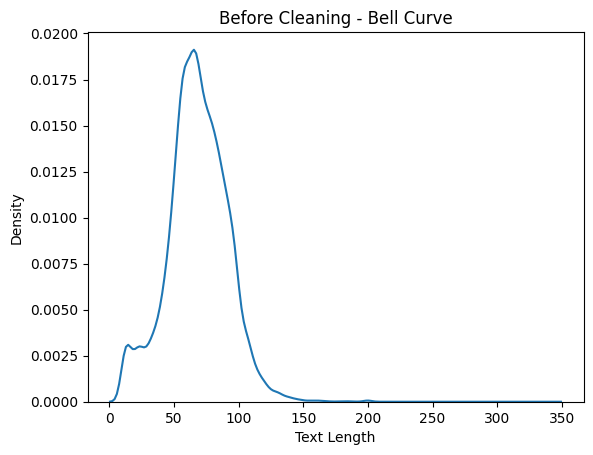

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.kdeplot(df["text_length_before"], fill=False)
plt.title("Before Cleaning - Bell Curve")
plt.xlabel("Text Length")
plt.ylabel("Density")
plt.show()

In [17]:
# Apply the cleaning function to the text column
df["clean_text"] = df["text"].apply(clean_text)

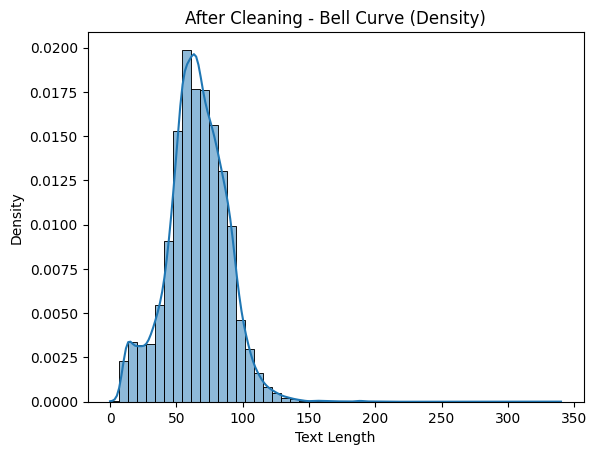

In [18]:
# AFTER CLEANING

# Create numerical column
df["text_length_after"] = df["clean_text"].apply(lambda x: len(str(x)))

sns.histplot(df["text_length_after"], bins=50, kde=True, stat="density")
plt.title("After Cleaning - Bell Curve (Density)")
plt.xlabel("Text Length")
plt.ylabel("Density")
plt.show()

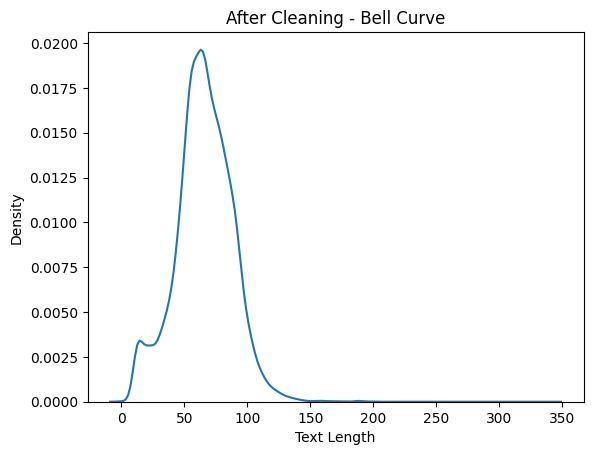

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df["text_length_after"], fill=False)
plt.title("After Cleaning - Bell Curve")
plt.xlabel("Text Length")
plt.ylabel("Density")
plt.show()

In [20]:
print(df[["text", "clean_text"]].head())

                                                text  \
0  BREAKING: First NFL Team Declares Bankruptcy O...   
1  Court Orders Obama To Pay $400 Million In Rest...   
2  UPDATE: Second Roy Moore Accuser Works For Mic...   
3         Oscar Pistorius Attempts To Commit Suicide   
4        Trump Votes For Death Penalty For Being Gay   

                                          clean_text  
0  breaking first nfl team declares bankruptcy ov...  
1   court orders obama to pay million in restitution  
2  update second roy moore accuser works for mich...  
3         oscar pistorius attempts to commit suicide  
4        trump votes for death penalty for being gay  


In [21]:
# ADVANCED PREPROCESSING 

# Import libraries needed for numerical processing and scaling 
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Make a copy of the cleaned dataframe to keep the original unchanged 
df_processed = df.copy()


In [22]:
# OUTLIER HANDLING USING IQR
# --------------------------------

# Calculate the first quartile (25%) and third quartile (75%)
Q1 = df_processed["text_length_after"].quantile(0.25)
Q3 = df_processed["text_length_after"].quantile(0.75)

# Calculate the interquartile range
IQR = Q3 - Q1

# Keep only rows within the acceptable range, removing extremely small or large text lengths
df_processed = df_processed[
    (df_processed["text_length_after"] >= Q1 - 1.5 * IQR) &
    (df_processed["text_length_after"] <= Q3 + 1.5 * IQR)
]

In [23]:
# LOG TRANSFORMATION 
# --------------------------------

# Apply log transformation to reduce skewness
# log1p means log(1 + x), which is safer when values include 0
df_processed["log_length"] = np.log1p(df_processed["text_length_after"])

In [24]:
# FEATURE SCALING
# --------------------------------

# Create the scaler
scaler = MinMaxScaler()

# Scale the log-transformed values into the range 0 to 1
df_processed["scaled_length"] = scaler.fit_transform(df_processed[["log_length"]])

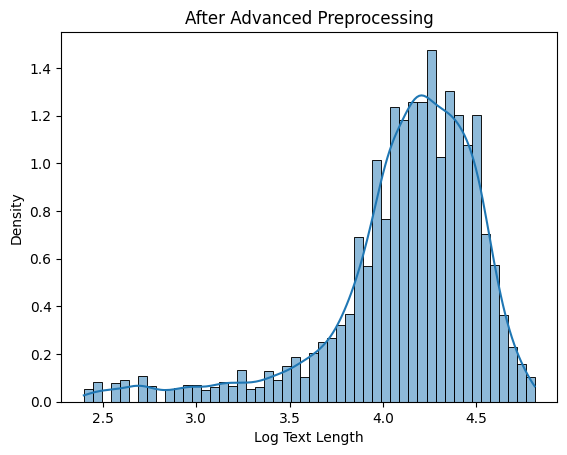

In [25]:
# VISUALISE THE IMPROVED DISTRIBUTION
# --------------------------------

# Plot the bell curve after advanced preprocessing
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_processed["log_length"], bins=50, kde=True, stat="density")
plt.title("After Advanced Preprocessing")
plt.xlabel("Log Text Length")
plt.ylabel("Density")
plt.show()

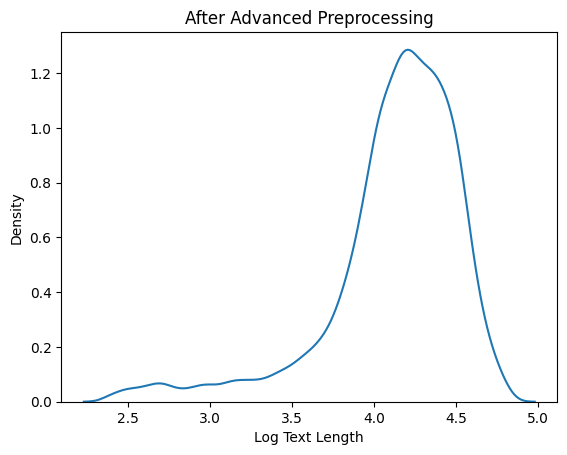

In [26]:
sns.kdeplot(df_processed["log_length"], fill=False)
plt.title("After Advanced Preprocessing")
plt.xlabel("Log Text Length")
plt.ylabel("Density")
plt.show()

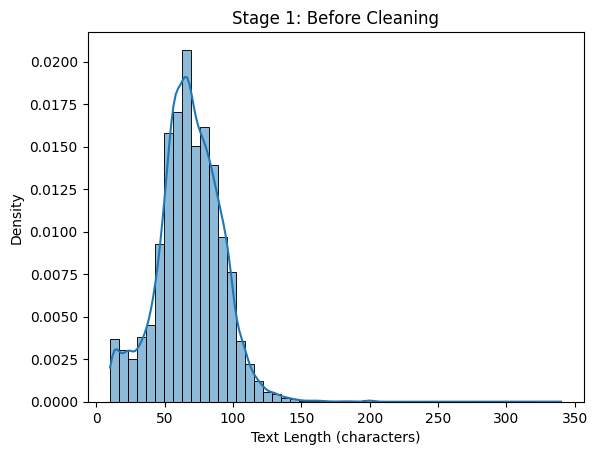

In [27]:
#  BEFORE CLEANING
# ----------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# Plot the text length distribution before any cleaning was applied
# This shows the raw character count of each news title
sns.histplot(df["text_length_before"], bins=50, kde=True, stat="density")
plt.title("Stage 1: Before Cleaning")
plt.xlabel("Text Length (characters)")
plt.ylabel("Density")
plt.show()


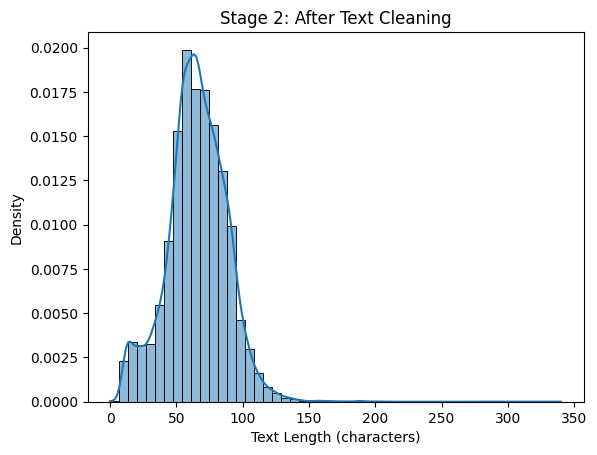

In [28]:
# AFTER CLEANING
# ----------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# Plot the text length distribution after basic text cleaning was applied
# Lowercase conversion, punctuation removal and whitespace stripping
sns.histplot(df["text_length_after"], bins=50, kde=True, stat="density")
plt.title("Stage 2: After Text Cleaning")
plt.xlabel("Text Length (characters)")
plt.ylabel("Density")
plt.show()

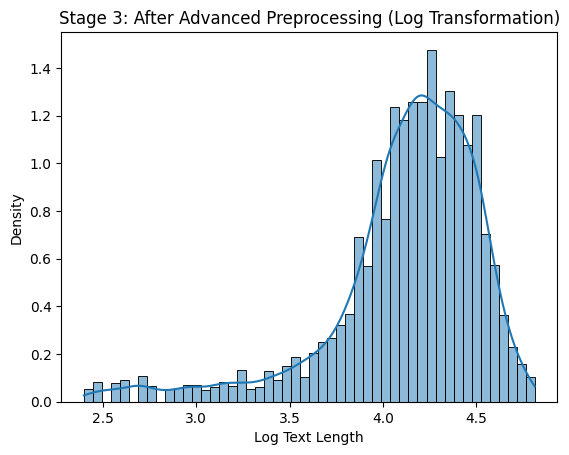

In [29]:
# AFTER ADVANCED PREPROCESSING
# ----------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# Plot the text length distribution after advanced preprocessing
# This includes outlier removal using IQR, log transformation 
# using log1p and Min-Max scaling to normalise values between 0 and 1
sns.histplot(df_processed["log_length"], bins=50, kde=True, stat="density")
plt.title("Stage 3: After Advanced Preprocessing (Log Transformation)")
plt.xlabel("Log Text Length")
plt.ylabel("Density")
plt.show()

In [30]:
# ----------------------------------------
# STATISTICAL SUMMARY - ALL THREE STAGES
# Shows mean, std, min and max for each stage
# to support the visual comparison above
# ----------------------------------------

print("=" * 55)
print("STAGE 1: Before Cleaning")
print("Variable: text_length_before (raw character count)")
print("=" * 55)
print(f"Mean:    {df['text_length_before'].mean():.2f}")
print(f"Std:     {df['text_length_before'].std():.2f}")
print(f"Min:     {df['text_length_before'].min():.2f}")
print(f"Max:     {df['text_length_before'].max():.2f}")

print("\n" + "=" * 55)
print("STAGE 2: After Text Cleaning")
print("Variable: text_length_after (cleaned character count)")
print("=" * 55)
print(f"Mean:    {df['text_length_after'].mean():.2f}")
print(f"Std:     {df['text_length_after'].std():.2f}")
print(f"Min:     {df['text_length_after'].min():.2f}")
print(f"Max:     {df['text_length_after'].max():.2f}")

print("\n" + "=" * 55)
print("STAGE 3: After Advanced Preprocessing")
print("Variable: log_length (log transformed)")
print("="* 55)
print(f"Mean:    {df_processed['log_length'].mean():.2f}")
print(f"Std:     {df_processed['log_length'].std():.2f}")
print(f"Min:     {df_processed['log_length'].min():.2f}")
print(f"Max:     {df_processed['log_length'].max():.2f}")

STAGE 1: Before Cleaning
Variable: text_length_before (raw character count)
Mean:    68.30
Std:     23.29
Min:     10.00
Max:     340.00

STAGE 2: After Text Cleaning
Variable: text_length_after (cleaned character count)
Mean:    65.54
Std:     22.52
Min:     0.00
Max:     340.00

STAGE 3: After Advanced Preprocessing
Variable: log_length (log transformed)
Mean:    4.12
Std:     0.41
Min:     2.40
Max:     4.81


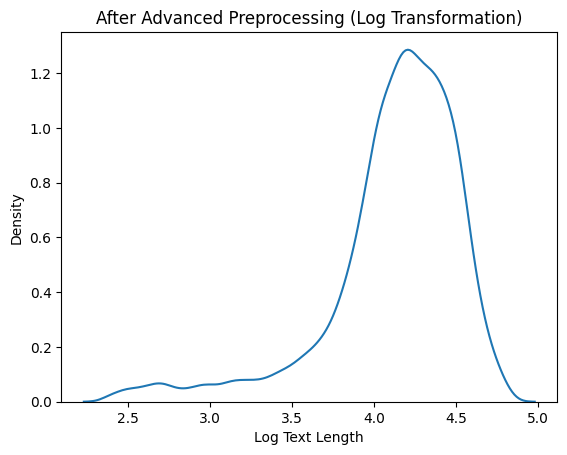

In [31]:
# ----------------------------------------
# FINAL KDE PLOT - AFTER ADVANCED PREPROCESSING
# Title specifies the normalisation techniques used
# ----------------------------------------

sns.kdeplot(df_processed["log_length"], fill=False)
plt.title("After Advanced Preprocessing "
          "(Log Transformation)")
plt.xlabel("Log Text Length")
plt.ylabel("Density")
plt.show()

In [32]:
X=df["clean_text"]
Y=df["label"]

In [33]:
from sklearn.model_selection import train_test_split

# Split the dataset into 80% for training and 20% for testing sets
# random_state=42 means the split will be the same every time I run it
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF vectorizer
# TF-IDF turns text into numbers the model can read
# stop_words removes common words like "the" and "and" that add no value
vectorizer= TfidfVectorizer(stop_words= 'english')

# Fit on training data and transform it 
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform test data using the same TF-IDF vectorizer
X_test_tfidf = vectorizer.transform( X_test)

# Check shapes 
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(18556, 17073)
(4640, 17073)


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Logistic Regression model is used as a baseline classifier

# Initialise the Logistic Regression model
# max_iter is increased to ensure the model converges during training
# random_state is set for reproducibility of results
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

# Train the model using the TF-IDF transformed training data
lr_model.fit(X_train_tfidf, Y_train)

# Generate predictions on the test dataset
Y_pred_lr = lr_model.predict(X_test_tfidf)

# Display model evaluation results
print("=" * 40)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 40)

# Print classification report showing precision, recall, and F1-score for each class
print(classification_report(Y_test, Y_pred_lr, target_names=["Real", "Fake"]))

# Calculate and display overall accuracy of the model
print("Accuracy:", round(accuracy_score(Y_test, Y_pred_lr) * 100, 2), "%")

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

        Real       0.90      0.86      0.88      3474
        Fake       0.63      0.72      0.67      1166

    accuracy                           0.82      4640
   macro avg       0.76      0.79      0.77      4640
weighted avg       0.83      0.82      0.83      4640

Accuracy: 82.24 %


In [36]:
from sklearn.naive_bayes import MultinomialNB


# Initialise the Naive Bayes model
nb_model = MultinomialNB()

# Train the model using the TF-IDF transformed training data
nb_model.fit(X_train_tfidf, Y_train)

# Generate predictions on the test dataset
Y_pred_nb = nb_model.predict(X_test_tfidf)

# Display model evaluation results
print("=" * 40)
print("NAIVE BAYES RESULTS")
print("=" * 40)

# Print classification report showing precision, recall, and F1-score for each class
print(classification_report(Y_test, Y_pred_nb, target_names=["Real", "Fake"]))

# Calculate and display overall accuracy of the model
print("Accuracy:", round(accuracy_score(Y_test, Y_pred_nb) * 100, 2), "%")

NAIVE BAYES RESULTS
              precision    recall  f1-score   support

        Real       0.81      0.99      0.89      3474
        Fake       0.88      0.33      0.48      1166

    accuracy                           0.82      4640
   macro avg       0.85      0.66      0.69      4640
weighted avg       0.83      0.82      0.79      4640

Accuracy: 82.11 %


In [37]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest builds multiple decision trees to improve prediction accuracy

# n_estimators defines the number of trees, while random_state keeps results consistent
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model using the TF-IDF transformed training data
rf_model.fit(X_train_tfidf, Y_train)

# Generate predictions on the test dataset
Y_pred_rf = rf_model.predict(X_test_tfidf)

# Display model evaluation results
print("=" * 40)
print("RANDOM FOREST RESULTS")
print("=" * 40)

# Print classification report showing precision, recall, and F1-score for each class
print(classification_report(Y_test, Y_pred_rf, target_names=["Real", "Fake"]))

# Calculate and display overall accuracy of the model
print("Accuracy:", round(accuracy_score(Y_test, Y_pred_rf) * 100, 2), "%")

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

        Real       0.86      0.93      0.90      3474
        Fake       0.73      0.56      0.63      1166

    accuracy                           0.84      4640
   macro avg       0.80      0.74      0.76      4640
weighted avg       0.83      0.84      0.83      4640

Accuracy: 83.73 %


In [38]:
from sklearn.svm import LinearSVC

# LinearSVC is an efficient SVM for high-dimensional TF-IDF data

# random_state ensures consistency and max_iter allows convergence
svm_model = LinearSVC(random_state=42, max_iter=1000, class_weight='balanced')

# Train the model using the TF-IDF transformed training data
svm_model.fit(X_train_tfidf, Y_train)

# Generate predictions on the test dataset
Y_pred_svm = svm_model.predict(X_test_tfidf)

# Display model evaluation results
print("=" * 40)
print("SVM RESULTS")
print("=" * 40)

# Print classification report showing precision, recall, and F1-score for each class
print(classification_report(Y_test, Y_pred_svm, target_names=["Real", "Fake"]))

# Calculate and display overall accuracy of the model
print("Accuracy:", round(accuracy_score(Y_test, Y_pred_svm) * 100, 2), "%")

SVM RESULTS
              precision    recall  f1-score   support

        Real       0.90      0.85      0.87      3474
        Fake       0.62      0.71      0.66      1166

    accuracy                           0.82      4640
   macro avg       0.76      0.78      0.77      4640
weighted avg       0.83      0.82      0.82      4640

Accuracy: 81.7 %


In [39]:
# ============================================================
# HYPERPARAMETER TUNING: GridSearchCV on SVM
# Testing a small range of C values to find the optimal setting for the LinearSVC model
# ============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

 # C controls how strictly the model fits the training data

param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

# Initialise the base SVM model
svm_tune = LinearSVC(random_state=42, max_iter=1000, class_weight='balanced')

# GridSearchCV tests each value of C using 5-fold cross validation
# and selects the one that produces the highest F1 score
grid_search = GridSearchCV(
    svm_tune,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Fit on training data
grid_search.fit(X_train_tfidf, Y_train)

# Display the best parameter found
print("=" * 40)
print("SVM HYPERPARAMETER TUNING RESULTS")
print("=" * 40)
print(f"Best C value: {grid_search.best_params_['C']}")
print(f"Best cross-validation F1 score: {round(grid_search.best_score_, 3)}")
print()

# Evaluate the tuned model on the test set
Y_pred_tuned = grid_search.best_estimator_.predict(X_test_tfidf)

print(classification_report(Y_test, Y_pred_tuned, target_names=['Real', 'Fake']))
print("Accuracy:", round(accuracy_score(Y_test, Y_pred_tuned) * 100, 2), "%")

SVM HYPERPARAMETER TUNING RESULTS
Best C value: 0.1
Best cross-validation F1 score: 0.659

              precision    recall  f1-score   support

        Real       0.90      0.86      0.88      3474
        Fake       0.63      0.72      0.67      1166

    accuracy                           0.82      4640
   macro avg       0.77      0.79      0.78      4640
weighted avg       0.83      0.82      0.83      4640

Accuracy: 82.35 %


In [40]:
# ============================================================
# BEFORE vs AFTER COMPARISON TABLE
# Comparing model performance before and after applying
# class_weight='balanced' to address class imbalance
# ============================================================

import pandas as pd


comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    
    # F1 scores before class weighting was applied
    'Baseline F1': [0.591, 0.606, 0.650],
    
    # F1 scores after class weighting was applied
    'Balanced F1': [0.671, 0.632, 0.661],
    
    # Recall scores before class weighting was applied
    # how many fake articles the model correctly identified
    'Baseline Recall': [0.463, 0.511, 0.580],
    
    # Recall scores after class weighting was applied
    'Balanced Recall': [0.722, 0.557, 0.711],
}

df_compare = pd.DataFrame(comparison_data)

# Display the comparison table
print("Impact of class_weight='balanced' on Fake News:")
print("=" * 65)
print(df_compare.to_string(index=False))
print("=" * 65)
print()

# Summary of key changes
print("Key findings:")
print(f"  - LR:  F1 0.591 -> 0.671 (+0.080) | Recall 0.463 -> 0.722 (+0.259)")
print(f"  - RF:  F1 0.606 -> 0.632 (+0.026) | Recall 0.511 -> 0.557 (+0.046)")
print(f"  - SVM: F1 0.650 -> 0.661 (+0.011) | Recall 0.580 -> 0.711 (+0.131)")
print()

Impact of class_weight='balanced' on Fake News:
              Model  Baseline F1  Balanced F1  Baseline Recall  Balanced Recall
Logistic Regression        0.591        0.671            0.463            0.722
      Random Forest        0.606        0.632            0.511            0.557
                SVM        0.650        0.661            0.580            0.711

Key findings:
  - LR:  F1 0.591 -> 0.671 (+0.080) | Recall 0.463 -> 0.722 (+0.259)
  - RF:  F1 0.606 -> 0.632 (+0.026) | Recall 0.511 -> 0.557 (+0.046)
  - SVM: F1 0.650 -> 0.661 (+0.011) | Recall 0.580 -> 0.711 (+0.131)



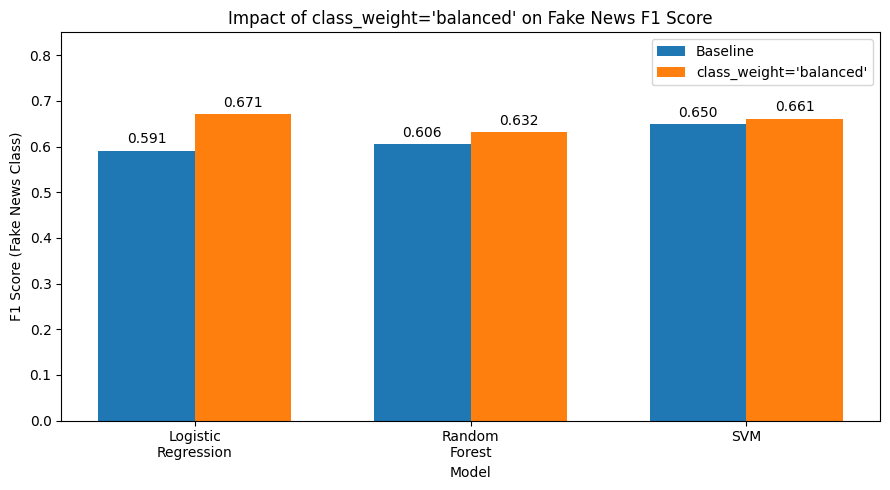

In [41]:
# ============================================================
# BAR CHART: Baseline vs Balanced F1 Score Comparison
# Visualising the impact of class weighting on F1 scores
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

models = ["Logistic\nRegression", "Random\nForest", "SVM"]

# F1 scores before and after class weighting
baseline_f1 = [0.591, 0.606, 0.650]
balanced_f1  = [0.671, 0.632, 0.661]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

# Plot baseline and balanced bars side by side
bars1 = ax.bar(x - width/2, baseline_f1, width, label='Baseline')
bars2 = ax.bar(x + width/2, balanced_f1, width, label="class_weight='balanced'")

# Labels and formatting
ax.set_xlabel('Model')
ax.set_ylabel('F1 Score (Fake News Class)')
ax.set_title("Impact of class_weight='balanced' on Fake News F1 Score")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 0.85)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)

plt.tight_layout()

# Save the chart as an image for use in the dissertation
plt.savefig('baseline_vs_balanced_f1.png', bbox_inches='tight')

plt.show()

In [42]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Create a DataFrame to compare model performance using multiple evaluation metrics
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Random Forest', 'SVM'],
    
    # Accuracy shows the overall percentage of correct predictions
    'Accuracy (%)': [
        round(accuracy_score(Y_test, Y_pred_lr) * 100, 2),
        round(accuracy_score(Y_test, Y_pred_nb) * 100, 2),
        round(accuracy_score(Y_test, Y_pred_rf) * 100, 2),
        round(accuracy_score(Y_test, Y_pred_svm) * 100, 2)
    ],
    
    # Precision measures how many predicted positives are actually correct
    'Precision': [
        round(precision_score(Y_test, Y_pred_lr), 3),
        round(precision_score(Y_test, Y_pred_nb), 3),
        round(precision_score(Y_test, Y_pred_rf), 3),
        round(precision_score(Y_test, Y_pred_svm), 3)
    ],
    
    # Recall measures how many actual positives were correctly identified
    'Recall': [
        round(recall_score(Y_test, Y_pred_lr), 3),
        round(recall_score(Y_test, Y_pred_nb), 3),
        round(recall_score(Y_test, Y_pred_rf), 3),
        round(recall_score(Y_test, Y_pred_svm), 3)
    ],
    
    # F1 Score balances precision and recall for overall performance evaluation
    'F1 Score': [
        round(f1_score(Y_test, Y_pred_lr), 3),
        round(f1_score(Y_test, Y_pred_nb), 3),
        round(f1_score(Y_test, Y_pred_rf), 3),
        round(f1_score(Y_test, Y_pred_svm), 3)
    ]
})

# Display the results table without row indices
print(results_df.to_string(index=False))

              Model  Accuracy (%)  Precision  Recall  F1 Score
Logistic Regression         82.24      0.627   0.722     0.671
        Naive Bayes         82.11      0.882   0.333     0.483
      Random Forest         83.73      0.732   0.557     0.632
                SVM         81.70      0.618   0.711     0.661


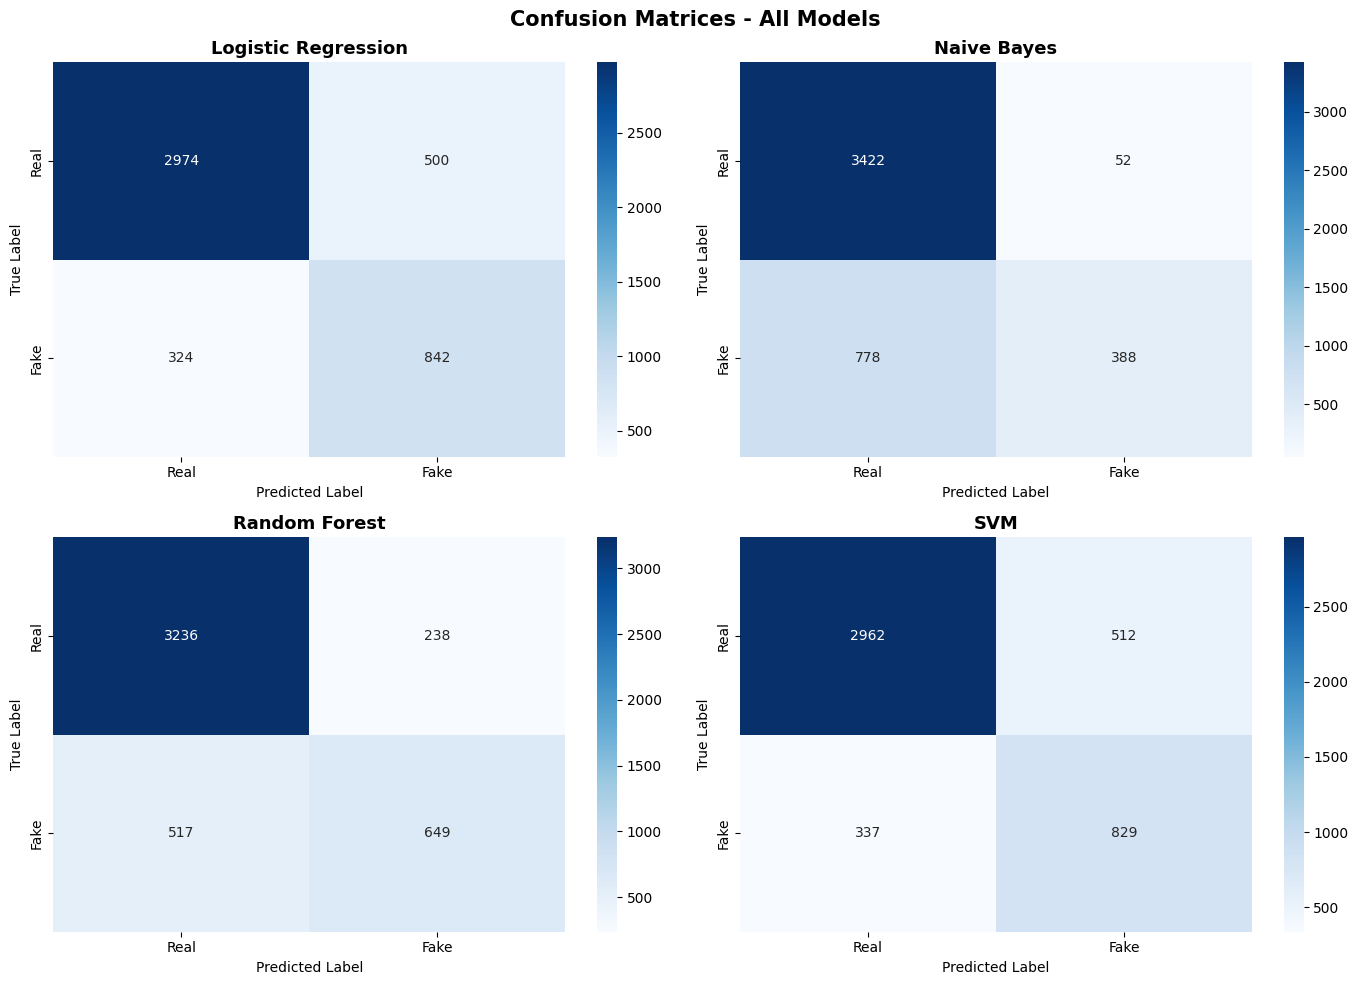

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot confusion matrices for all models to visualise classification performance
# Each matrix shows correct and incorrect predictions for Real and Fake classes

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Store model names and their predictions for iteration
models_info = [
    ('Logistic Regression', Y_pred_lr),
    ('Naive Bayes', Y_pred_nb),
    ('Random Forest', Y_pred_rf),
    ('SVM', Y_pred_svm)
]

# Loop through each model and plot its confusion matrix
for ax, (name, preds) in zip(axes.flatten(), models_info):
    cm = confusion_matrix(Y_test, preds)
    
    # Display confusion matrix as a heatmap
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'])
    
    # Set titles and axis labels
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

# Add overall title and adjust layout
plt.suptitle('Confusion Matrices - All Models', fontsize=15, fontweight='bold')
plt.tight_layout()

# Save the figure for use in the report
plt.savefig('confusion_matrices.png', bbox_inches='tight')

# Display the plots
plt.show()

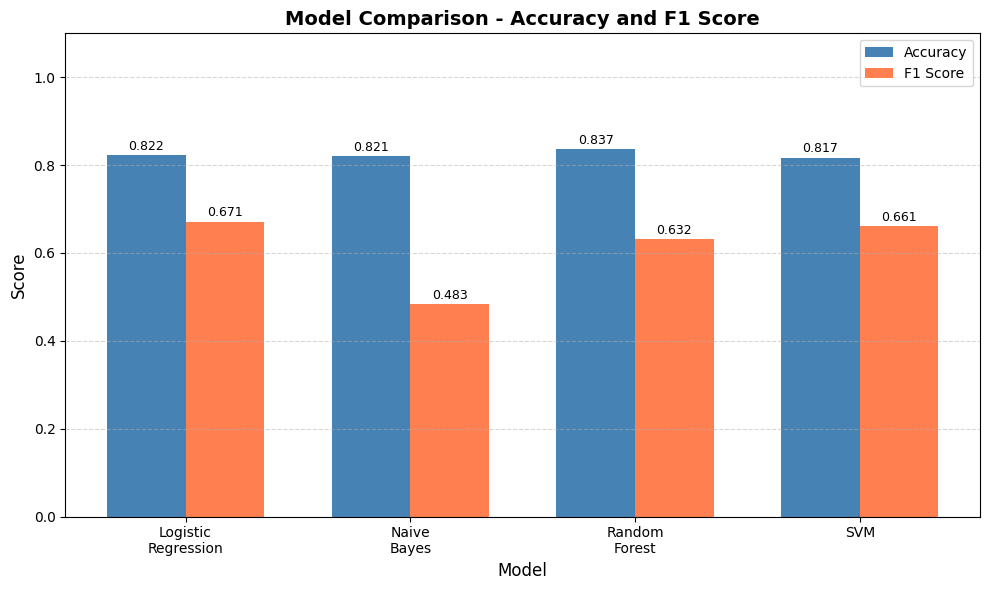

In [44]:
import numpy as np 

# Create a bar chart to compare model performance using Accuracy and F1 Score
# F1 score is more suitable than accuracy for imbalanced data, as it considers both false positives and false negatives

# Define model names (formatted for better display on the x-axis)
models = ['Logistic\nRegression', 'Naive\nBayes', 'Random\nForest', 'SVM']

# Calculate accuracy for each model
accuracy = [
    accuracy_score(Y_test, Y_pred_lr),
    accuracy_score(Y_test, Y_pred_nb),
    accuracy_score(Y_test, Y_pred_rf),
    accuracy_score(Y_test, Y_pred_svm)
]

# Calculate F1 score for each model
f1 = [
    f1_score(Y_test, Y_pred_lr),
    f1_score(Y_test, Y_pred_nb),
    f1_score(Y_test, Y_pred_rf),
    f1_score(Y_test, Y_pred_svm)
]

# Set positions for bars on the x-axis
x = np.arange(len(models))
width = 0.35  # Width of each bar

# Create the figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Plot accuracy and F1 score bars side by side
bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, f1, width, label='F1 Score', color='coral')

# Add value labels on top of each accuracy bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)

# Add value labels on top of each F1 score bar
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)

# Set axis labels and chart title
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison - Accuracy and F1 Score', fontsize=14, fontweight='bold')

# Configure x-axis ticks and labels
ax.set_xticks(x)
ax.set_xticklabels(models)

# Set y-axis limits and add legend and grid
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Adjust layout, save the figure, and display the chart
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

In [45]:
import pickle

# Saving the best model and vectorizer so they can be loaded into the dashboard
# I will update best_model once I have reviewed the results above

best_model = svm_model  
best_model_name = "SVM"  

# Write the trained model to a file
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Write the fitted vectorizer to a file.
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print(f"Saved: {best_model_name}")
print("Saved: vectorizer.pkl")

Saved: SVM
Saved: vectorizer.pkl
